In [4]:
import pandas as pd

train = pd.read_excel("/Symptom Classification dataset - 2 -- Train.xlsx") # Training data
valid = pd.read_excel("/Symptom Classification dataset - 2 -- Val.xlsx") # Validation data
test  = pd.read_excel("/Symptom Classification dataset - 2 -- Test.xlsx") # Testing data
# Converting the text data into array for easier access and modification

train_data = train['text'].tolist()
val_data = valid['text'].tolist()
test_data = test['text'].tolist()

In [5]:
# Training text data
train_data


['Sally is around the same age, 25 I assume, (can’t confirm numbers, sorry about that) and she quickly became a red flag for me. He would mention her name occasionally and how our love for the same type of shows was shared with Sally. Sally and I met a few times. The first time was when we planned a day out shopping with a mutual friend who was single at the time and my bf decided to invite Sally. I thought that was a little weird, but justified it because 1) I had never met her and thought that would be a great opportunity to and 2) He said maybe the two of them would hit it off.',
 'Every once and a while I will get this over whelming feeling in my head where I feel really out of it, and freaked out. I will feel like I haven’t slept in a bit, I don’t feel like me. I’m anxious but also tired and I wanna just go take a nap. But my inner self tells me that I am going to have a seizure. I don’t have seizures or anything and I am completely healthy.',
 'Then about 25 minutes later I got a

In [6]:
# Validation text data

val_data


["She never messaged him back, but I asked her why she still had him on Snapchat. I only asked it because she had claimed to have deleted her ex's on social media. Whatever, that's a nice feeling and I'm glad, but at the same time it wouldn't really be an issue for me if she did still have them. Fast forward to last night... My fiance was acting all weird and put out so I tried figure out what was going on and what she was upset about.",
 'Dear reddit, For what I am about to tell you today is not a rant from a "man", but a voice of a concerned human being who happens to be male. Victims of domestic violence who are men are being laughed at and not taken seriously in today\'s society. It seems the society has made up their mind that men could not be victims of female violence because the male is "much bigger", therefore the male has some kind of "agenda" against the female. I was punched and slapped in the face two weeks ago by my wife who is 5\'2 103lbs.',
 "I won't defend myself, I kn

In [7]:
# Test text data
test_data

['I blocked him on FB and then deactivated. One two punch, because my FB addiction is another obstacle in my life. I\'m very proud of these decisions, but it also meant leaving my "Thrive After Abuse" group. So now here I am on Reddit, hoping to find another supportive community. Best wishes to all.',
 "-I'm not doing this for people to MAKE money, but to help those struggling to feed themselves and/or family. My days of that are over. -if any supermarkets or stores offer similar promotions in other countries, let me know and I'll look into what can be done. DM me regarding this. And remember, anything spare you have, please donate to food banks.",
 'one day i broke down into absolute tears and was rushed into the counselers office. at this point im in 8th grade and this is by no means acceptable behavior. we are about to go into high school and i just burst into a ball of tears in front of every last one of my peers. the good thing is, this scenario made me care a little less about wh

In [8]:
# Download everything needed

import nltk
nltk.download('averaged_perceptron_tagger')

# Used for tokenization
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

# For stopword removal
from nltk.corpus import stopwords
nltk.download('stopwords')

# For Lemmitization
from nltk.stem import WordNetLemmatizer

# For text cleaning
import string
import re

# For handling contractions
!pip install contractions
import contractions

# For handling special cases (numbers, urls, hashtags, etc)
!pip install textacy
from textacy import preprocessing

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.7/210.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.6/321.6 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 56.0 MB/s eta 0:00:00


In [16]:
top_words = set(stopwords.words('english')) # Created a variable to save the collection of stopwords
lemmatizer = WordNetLemmatizer() # Created a variable that can be later called to use the Lemmatizer

def clean_text(text): # Function to clean all the text

    processed_data = [] # new list varialbe to store the preprocessed text

    for each_sent in text: # To iterate one text cell at a time

        # Contractions fixed
        each_sent = contractions.fix(each_sent)

        # Lowercasing
        each_sent = each_sent.lower()

        # Punctuation Removal
        each_sent = re.sub(r'(\d+)([a-zA-Z])', r'\1 \2', each_sent) #  Keep the gaps after removing punctuations
        each_sent = re.sub(r'([a-zA-Z])(\d+)', r'\1 \2', each_sent)
        each_sent = re.sub(r'[%s]' % re.escape(string.punctuation), '', each_sent) # Removes punctuation
        each_sent = re.sub(r'[^\w\s]', '', each_sent)

        # Removes whitespaces
        each_sent = re.sub(r'[\s+]', ' ', each_sent).strip() # Changed to raw string literal

        # Special Cases
        each_sent= preprocessing.replace.urls(each_sent, repl = '_url_')
        each_sent = preprocessing.replace.hashtags(each_sent, repl = '_hashtag_')
        each_sent = preprocessing.replace.emails(each_sent, repl = '_email_')
        each_sent = preprocessing.replace.user_handles(each_sent, repl = '_user_')

        # Tokenize
        tokens = word_tokenize(each_sent)

        # Remove stopwords
        tokens = [word for word in tokens if word not in top_words]

        # Lemmatize
        tokens = [lemmatizer.lemmatize(word) for word in tokens]

        # Join the tokens again into one sentence
        tokens = ' '.join(tokens)

        processed_data.append(tokens)

    return processed_data

train_data[2352]

"Posting on a throwaway. As a paramedic student I was working in a Detroit ER, and an 8 year old girl came in. Her babysitter (15 years old) couldn't find her (for 10 minutes) and ultimately found her face down in a swimming pool. The local fire dept. responded, initiated care and transported to the facility I was working at."

In [17]:
processed_train_data = clean_text(train_data)
processed_train_data[2352]

'posting throwaway paramedic student working detroit er 8 year old girl came babysitter 15 year old could find 10 minute ultimately found face swimming pool local fire dept responded initiated care transported facility working'

In [11]:
val_data[1134]

"(God bless.) He was very caring at a first glance, but as the relationship went on I started discovering deeper things about him. Please be understanding that at the time I dated this guy I was around 14 or 15. He got off to IRL gore. You may think, well that's weird, but that's not the abusive part."

In [14]:
processed_valid_data = clean_text(val_data)
processed_valid_data[1134]


'god bless caring first glance relationship went started discovering deeper thing please understanding time dated guy around 14 15 got irl gore may think well weird abusive part'

EDA

In [18]:
# POS Tags

import spacy

nlp = spacy.load('en_core_web_sm')

for i in range(len(processed_train_data)):
  doc = nlp(processed_train_data[i])
  for token in doc:
    print('Word: {}, POS Tag: {}'.format(token.text, token.tag_))


Streaming output truncated to the last 5000 lines.
Word: finally, POS Tag: RB
Word: rejoined, POS Tag: VBD
Word: real, POS Tag: JJ
Word: one, POS Tag: CD
Word: edit, POS Tag: NN
Word: typo, POS Tag: NN
Word: fault, POS Tag: NN
Word: feel, POS Tag: VB
Word: like, POS Tag: IN
Word: fault, POS Tag: NN
Word: feel, POS Tag: VB
Word: like, POS Tag: IN
Word: reason, POS Tag: NN
Word: mother, POS Tag: NN
Word: bury, POS Tag: NN
Word: boy, POS Tag: NN
Word: better, POS Tag: JJR
Word: friend, POS Tag: NN
Word: mind, POS Tag: NN
Word: control, POS Tag: NN
Word: feel, POS Tag: VBP
Word: try, POS Tag: NN
Word: get, POS Tag: VB
Word: away, POS Tag: RP
Word: like, POS Tag: IN
Word: using, POS Tag: VBG
Word: drug, POS Tag: NN
Word: escape, POS Tag: NN
Word: drug, POS Tag: NN
Word: dissociating, POS Tag: NN
Word: place, POS Tag: NN
Word: want, POS Tag: VBP
Word: feel, POS Tag: VB
Word: forced, POS Tag: JJ
Word: reality, POS Tag: NN
Word: would, POS Tag: MD
Word: angry, POS Tag: JJ
Word: terrified, POS 

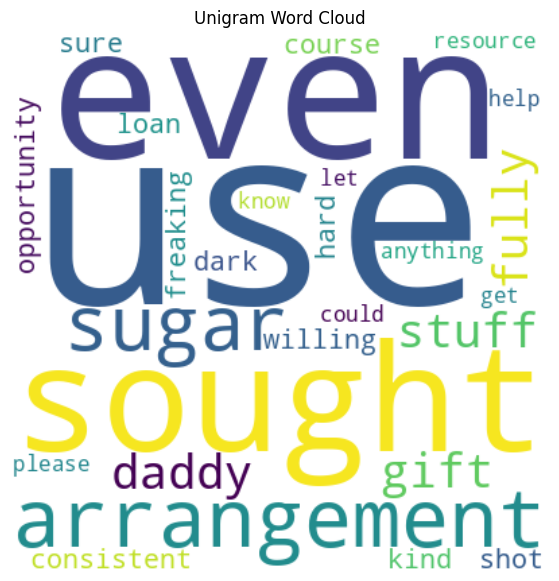

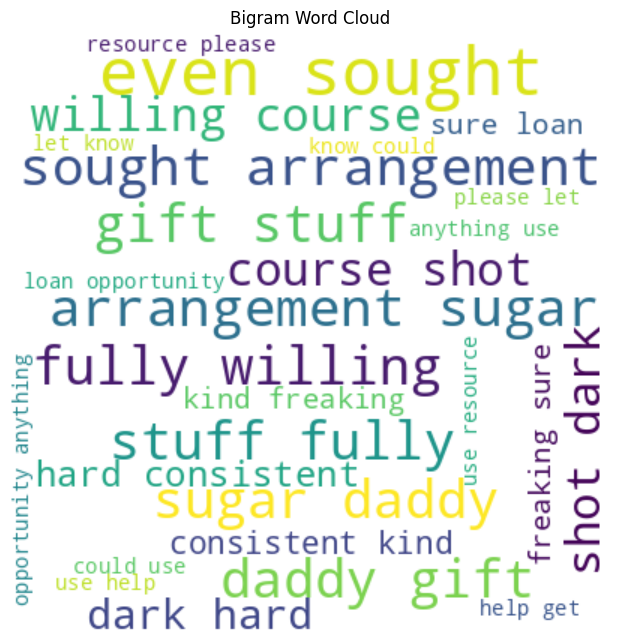

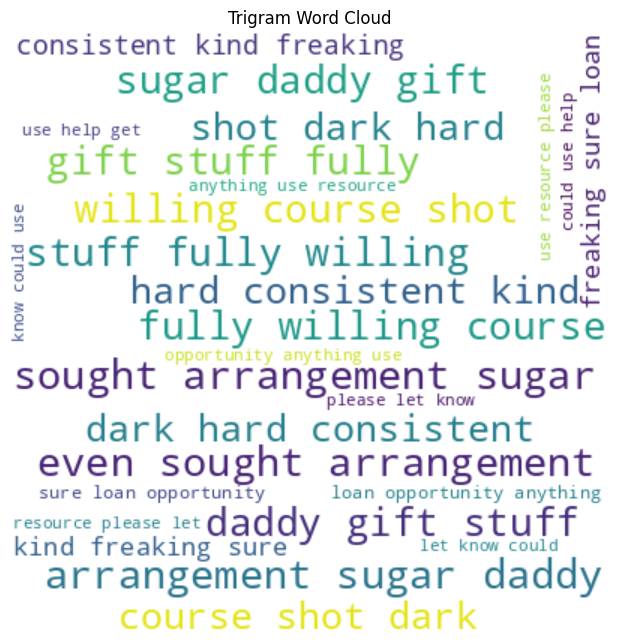

In [19]:
from nltk import pos_tag
from nltk import bigrams, trigrams
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk import FreqDist
from collections import Counter

# unigram
for text in processed_train_data:
  tokens = word_tokenize(text)
  unigrams = FreqDist(tokens)

wordcloud = WordCloud(width = 400, height = 400, background_color = 'white', colormap = 'viridis').generate_from_frequencies(unigrams)
plt.figure(figsize = (10, 7))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.title('Unigram Word Cloud')
plt.axis('off')
plt.show()
print()

# Bigram
for text in processed_train_data:
  tokens = word_tokenize(text)
  bigrams_list = list(bigrams(tokens))
  bigram_phrases = [' '.join(grams) for grams in bigrams_list]
  bigrams_freq = Counter(bigram_phrases)

wordcloud = WordCloud(width = 400, height = 400, background_color = 'white', colormap = 'viridis').generate_from_frequencies(bigrams_freq)

plt.figure(figsize = (6,6), facecolor = None)
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.tight_layout(pad = 0)
plt.title('Bigram Word Cloud')
plt.show()
print()

# Trigrams
for text in processed_train_data:
  tokens = word_tokenize(text)
  trigrams_list = list(trigrams(tokens))
  trigrams_phrases = [' '.join(grams) for grams in trigrams_list]
  trigrams_freq = Counter(trigrams_phrases)

wordcloud = WordCloud(width = 400, height = 400, background_color = 'white', colormap = 'viridis').generate_from_frequencies(trigrams_freq)

plt.figure(figsize = (6,6), facecolor = None)
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.tight_layout(pad = 0)
plt.title('Trigram Word Cloud')
plt.show()

Text Classification

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [25]:
processed_test_data = clean_text(test_data)

train['clean_text'] = processed_train_data
valid['clean_text'] = processed_valid_data
test['clean_text'] = processed_test_data

In [22]:
tfidf = TfidfVectorizer(max_features=5000)

X_train = tfidf.fit_transform(processed_train_data)
y_train = train['labs']

X_val = tfidf.transform(processed_valid_data)
y_val = valid['labs']

In [23]:
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [24]:
train_pred = model.predict(X_train)
val_pred = model.predict(X_val)

print("Training Macro Recall:", recall_score(y_train, train_pred, average='macro'))
print("Validation Macro Recall:", recall_score(y_val, val_pred, average='macro'))

Training Macro Recall: 0.9170557111733582
Validation Macro Recall: 0.8246109554933085


In [26]:
processed_test_data = clean_text(test_data) # Use the already loaded 'test' DataFrame
X_test = tfidf.transform(processed_test_data)
test_pred = model.predict(X_test)

test_pred

array([0, 0, 1, ..., 0, 1, 1])

In [27]:
submission = pd.DataFrame({'predicted': test_pred})
submission.to_csv("LogReg_test_predictions.csv", index=False)
